# Possible new features:
- <span style="color: red;">adjusted_points</span>: It is a measure of how good a cyclist is based on his position, the number of races he partecipated to and the points of the race: the average position is note enough because if a cyclist avg position is 2 but he made only 1 race we can'te be sure that he is a good cyclist. The same is for the avg position of multiple races, if a cyclist avg position is 2 and he partacipated to 30 races but each race has a low points score, it is different from a top tier cyclist who partecipated in 30 races with high score and has avg position of 2.
We wanted also to give a measure of points earned by a cyclist.\
The formula combine everything in this way: <span style="color: yellow;">adjusted_points = points / sqrt(position + 1)</span>\
The square root is useful to "decay" the number of points assigned to a cyclist in a non linear way.
- <span style="color: red;">BMI (Body Mass Index)</span>: Calculate BMI for each cyclist using weight and height. This could be correlated with performance metrics, especially on different terrain types or difficulty levels.
- <span style="color: red;">scaled_position</span>: Scale the finish position to a [0, 1]: <span style="color: yellow;">scaled_position= position−min(position) / max(position)−min(position)</span>
- <span style="color: red;">scaled_adjusted_points</span>: it is the same as adjusted_points, but we use scaled_position: <span style="color: yellow;">scaled_adjusted_points = points / sqrt(scaled_poistion + 1)</span>
- <span style="color: red;">profile_x_adp</span>: It is a measure of how good a cyclist is good in a given profile. The formula is the same as 'adjusted_points' but is calculated only with respect to the profile of the race, we end up with 5 different features.
- <span style="color: red;">season_x_adp</span>: It is a measure of how good a cyclist is good in a given season. The formula is the same as 'adjusted_points' but is calculated only with respect to the season of the race, we end up with 4 different features.
- <span style="color: red;">Average finish position across all races in which the cyclist participated</span>: This could indicate the cyclist’s general ranking capability, but it favorites cyclists who made very few races or easy races and placed in top positions.
- <span style="color: red;">Season-Wise Performance</span>: Create a season feature and calculate metrics like average finish position, points, or time delta for each season. This could reveal if certain cyclists perform better at specific times of the year.
- <span style="color: red;">Consistency Score</span>: Calculate the standard deviation of finish positions or points over multiple races. A lower standard deviation could indicate consistent performance.
- <span style="color: red;">Age standard deviation</span>: Calculate the standard deviation of the cyclist age. A high standard deviation in this case could mean a longer career.

For the future:
- Try to work with "length" of the races or consider circuit and races in a distinct way: until now we considered "circuit" as "races", but it might lead to some bias, because a cyclist can make a single race (e.g. Tour de France) which is made of a series of circuits and still have more races than a cyclist who made 10 different races.
- Deal with outliers.

In [1]:
!pip install "numpy<2"


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip list

Package           Version
----------------- -----------
asttokens         2.4.1
colorama          0.4.6
comm              0.2.2
contourpy         1.3.0
cycler            0.12.1
debugpy           1.8.6
decorator         5.1.1
executing         2.1.0
fonttools         4.54.1
ipykernel         6.29.5
ipython           8.28.0
jedi              0.19.1
joblib            1.4.2
jupyter_client    8.6.3
jupyter_core      5.7.2
kiwisolver        1.4.7
llvmlite          0.43.0
matplotlib        3.9.2
matplotlib-inline 0.1.7
nest-asyncio      1.6.0
numba             0.60.0
numpy             1.26.4
packaging         24.1
pandas            2.2.3
parso             0.8.4
pillow            10.4.0
pip               24.2
platformdirs      4.3.6
prompt_toolkit    3.0.48
psutil            6.0.0
pure_eval         0.2.3
Pygments          2.18.0
pyparsing         3.1.4
python-dateutil   2.9.0.post0
pytz              2024.2
pywin32           306
pyzmq             26.2.0
scikit-learn      1.5.2
scipy            

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import gzip
import numpy as np

In [2]:
with gzip.open('filtered_clean_merged_df.pkl', 'r') as file:
    filtered_clean_dataset = pickle.load(file)

In [3]:
filtered_clean_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 474476 entries, 0 to 475398
Data columns (total 20 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   _url_x             474476 non-null  object        
 1   name_x             474476 non-null  object        
 2   birth_year         474476 non-null  int64         
 3   weight             474476 non-null  int64         
 4   height             474476 non-null  int64         
 5   nationality        474476 non-null  object        
 6   race_id            474476 non-null  object        
 7   name_y             474476 non-null  object        
 8   points             474476 non-null  int64         
 9   length             474476 non-null  int64         
 10  profile            474476 non-null  int64         
 11  startlist_quality  474476 non-null  int64         
 12  date               474476 non-null  datetime64[ns]
 13  position           474476 non-null  int64        

In [4]:
cyclists = pd.DataFrame()

# Create seasons:
- Spring : 1
- Summer : 2
- Autumn : 3
- Winter : 4

In [6]:
from utils import map_to_season

# Apply the function to create a new 'season' column
filtered_clean_dataset['season'] = filtered_clean_dataset['month_day'].apply(map_to_season)

filtered_clean_dataset.head()

,_url_x,name_x,birth_year,weight,height,nationality,race_id,name_y,points,length,...,startlist_quality,date,position,cyclist,cyclist_age,is_tarmac,delta,year,month_day,season
0,bruno-surra,Bruno Surra,1964,72,187,Italy,vuelta-a-espana/1989/stage-1,Vuelta a España,80,20100,...,803,1989-04-24 00:25:33,110,bruno-surra,25,True,15,1989,04-24,1
1,gerard-rue,Gérard Rué,1965,74,182,France,tour-de-france/1997/stage-2,Tour de France,100,262000,...,1994,1997-07-07 06:27:47,132,gerard-rue,32,True,0,1997,07-07,2
2,gerard-rue,Gérard Rué,1965,74,182,France,tour-de-france/1990/stage-1,Tour de France,100,138500,...,1959,1990-07-01 03:29:36,66,gerard-rue,25,True,635,1990,07-01,2
3,gerard-rue,Gérard Rué,1965,74,182,France,tour-de-france/1992/stage-7,Tour de France,100,196500,...,2047,1992-07-11 04:22:52,35,gerard-rue,27,True,65,1992,07-11,2
4,gerard-rue,Gérard Rué,1965,74,182,France,tour-de-france/1990/stage-9,Tour de France,100,196000,...,1959,1990-07-09 04:46:44,41,gerard-rue,25,True,37,1990,07-09,2


Let's see the amount of races by each season

In [7]:
unique_races = filtered_clean_dataset.drop_duplicates(subset='race_id')

circuits_for_season = unique_races['season'].value_counts(normalize=True) * 100

circuits_for_season = pd.DataFrame({'season':circuits_for_season.index, 'percentage':circuits_for_season.values})
circuits_for_season['percentage'][0]
print(f"spring: {circuits_for_season['percentage'][0]}")
print(f"summer: {circuits_for_season['percentage'][1]}")
print(f"autumn: {circuits_for_season['percentage'][2]}")
print(f"winter: {circuits_for_season['percentage'][3]}")



spring: 41.36994568497284
summer: 39.77066988533494
autumn: 17.260108630054315
winter: 1.5992757996378997


Let'see explore some races and see the usual period they are made

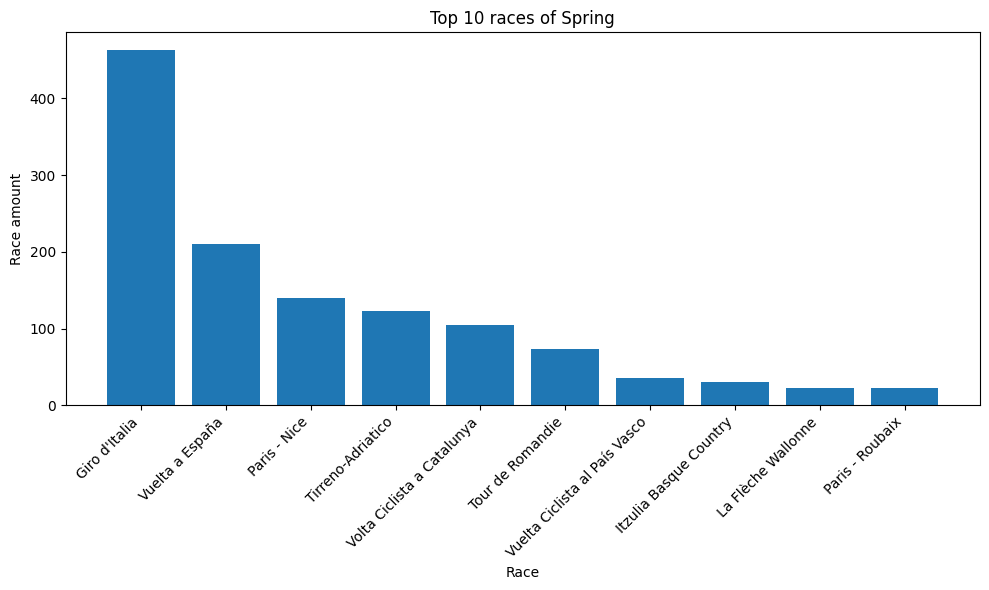

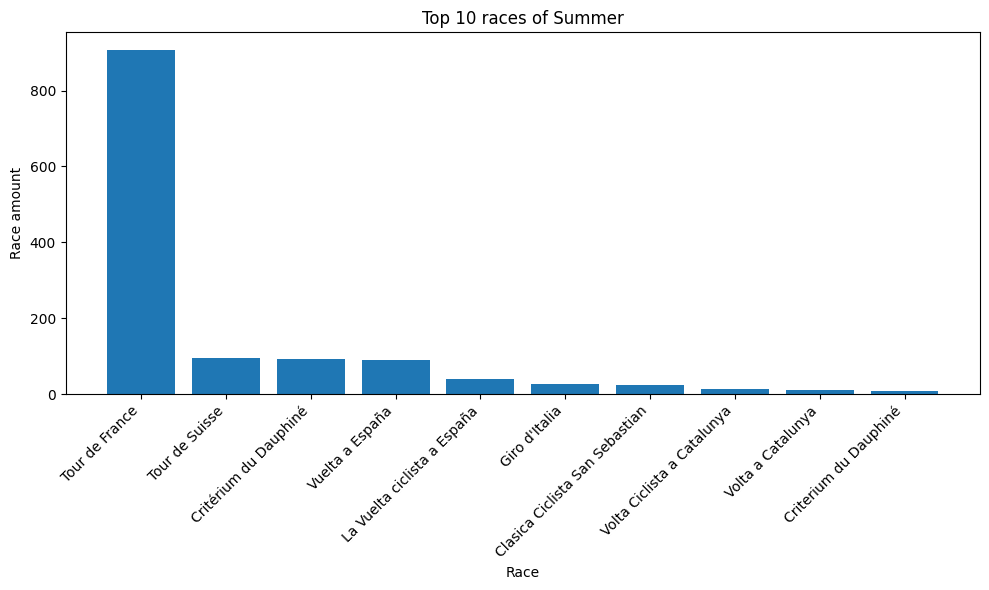

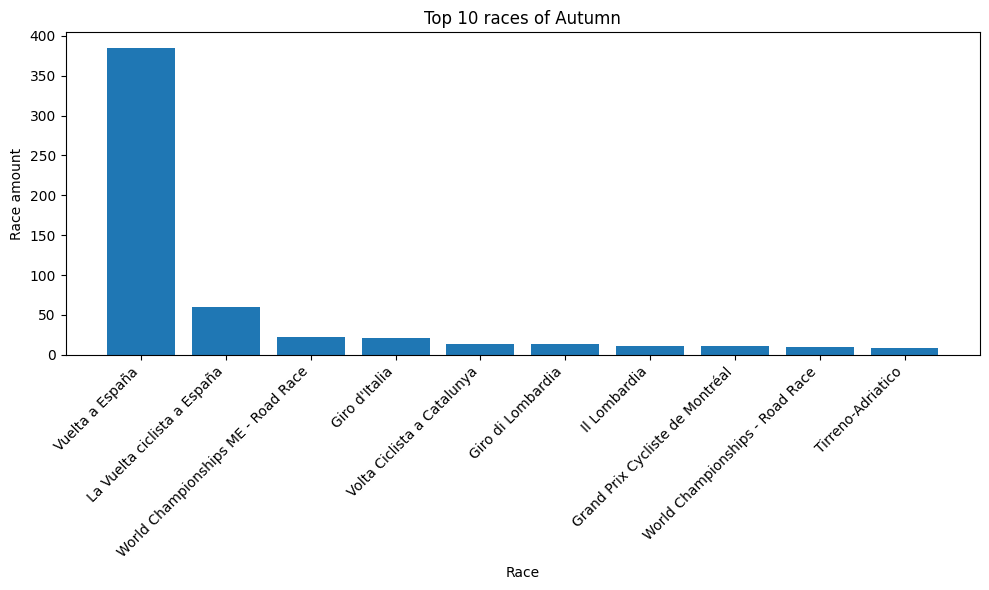

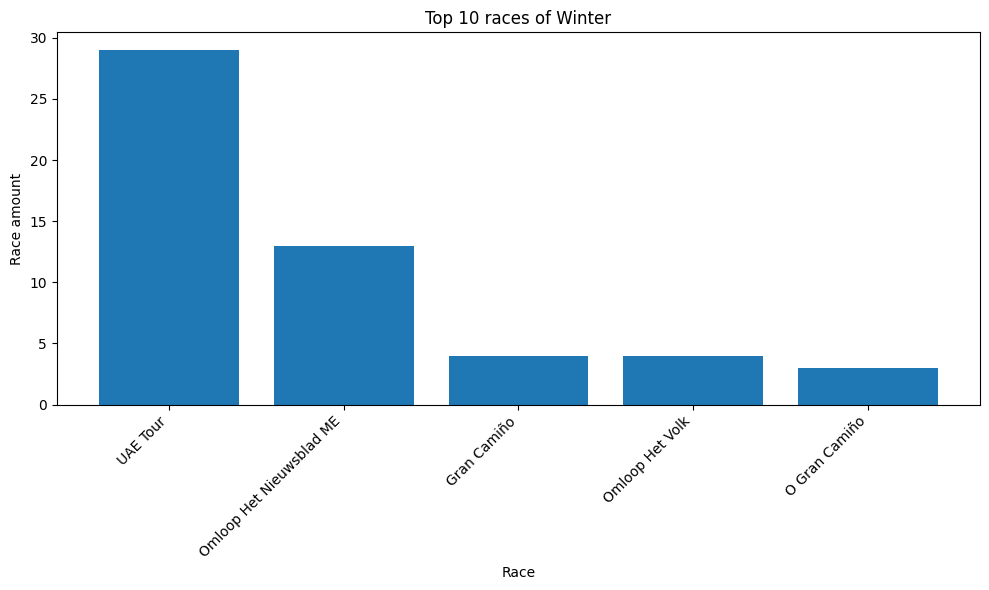

In [8]:
top_k = 10
seasons = {
    1: 'Spring',
    2: 'Summer',
    3: 'Autumn',
    4: 'Winter'
}

for i in range(1,5):
    season = filtered_clean_dataset[filtered_clean_dataset['season'] == i]
    season = season.drop_duplicates(subset='race_id')
    races_counts = season.groupby('name_y').size().reset_index(name='races_amount')
    races_counts = races_counts.sort_values(by='races_amount', ascending=False)

    top = races_counts.head(top_k)
    plt.figure(figsize=(10, 6))
    plt.bar(top['name_y'], top['races_amount'])
    plt.title(f'Top {top_k} races of {seasons[i]}')
    plt.xlabel('Race')
    plt.ylabel('Race amount')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

From what we can see from the plots:
- Giro d'italia is made in Spring
- Tour de France is made in Autumn
- Vuelta d'espana is a strange one, because it appears in 3 different seasons, but according to wikipedia: 'It was originally held in the spring, usually late April, with a few editions held in June in the 1940s. In 1995, however, the race moved to September to avoid direct competition with the Giro d'Italia, held in May.' That's why it appears in multiple seasons.

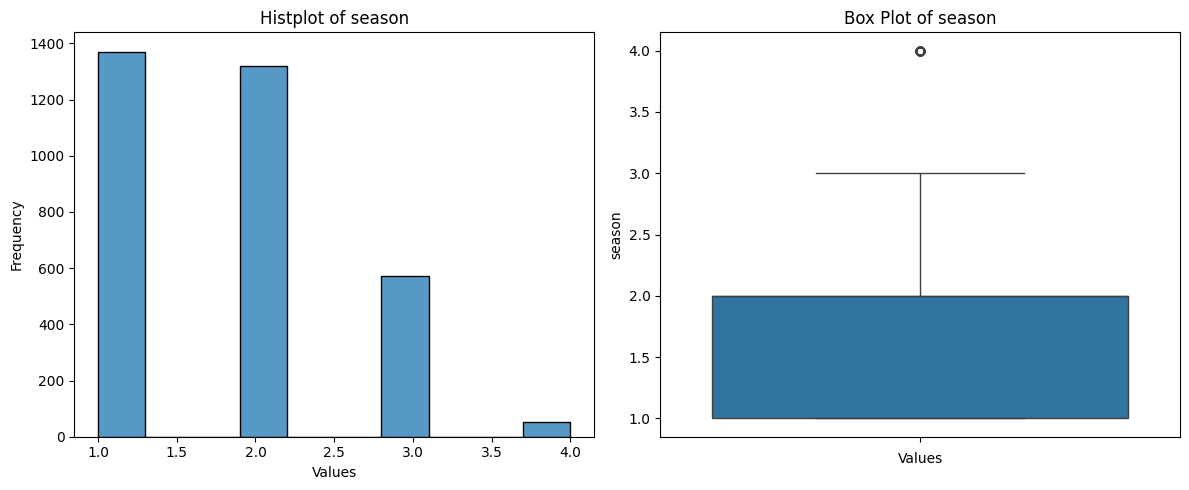

In [9]:
from utils import box_hist_plot

box_hist_plot(columns_to_select=['season'],
              dataset=unique_races,
              n_bins=10,
              kde=False)

- Create the features we discussed at the start of the file.

In [10]:
# calculate the adjusted points per race using the formula -> points / sqrt(position + 1)
filtered_clean_dataset['adjusted_points'] = filtered_clean_dataset['points'] / np.sqrt(filtered_clean_dataset['position'] + 1)

# Normalize position by dividing it by points or startlist_quality, 
# which gives a relative position score that accounts for race prestige or difficulty.
filtered_clean_dataset['normalized_position_points'] = filtered_clean_dataset['position'] / filtered_clean_dataset['points']
filtered_clean_dataset['normalized_position_startlist'] = filtered_clean_dataset['position'] / filtered_clean_dataset['startlist_quality']

filtered_clean_dataset['scaled_position'] = filtered_clean_dataset.groupby('race_id')['position'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)

filtered_clean_dataset['scaled_adjusted_points'] = filtered_clean_dataset['points'] / np.sqrt(filtered_clean_dataset['scaled_position'] + 1)

# Create body mass index weight/(height*100)^2
filtered_clean_dataset['bmi'] = filtered_clean_dataset['weight'] / ((filtered_clean_dataset['height']/100) **2)

In [11]:
# create cyclists dataset, start from the features we had or the features we created now and make the average or the sum
cyclists = filtered_clean_dataset.groupby('cyclist').agg({
    'birth_year': 'first',
    'bmi': 'first',
    'cyclist_age': 'mean',
    'adjusted_points': 'sum',
    'scaled_adjusted_points': 'sum',
    'position': 'mean',
    'profile': 'mean',
    'normalized_position_points': 'mean',
    'normalized_position_startlist': 'mean',
}).reset_index()

# change some names for easier understanding
cyclists.rename(columns={'profile': 'average_profile'}, inplace=True)
cyclists.rename(columns={'cyclist_age': 'average_cyclist_age'}, inplace=True)
cyclists.rename(columns={'normalized_position_points': 'average_normalized_position_points'}, inplace=True)
cyclists.rename(columns={'normalized_position_startlist': 'average_normalized_position_startlist'}, inplace=True)
cyclists.rename(columns={'position': 'average_position'}, inplace=True)


- Creation of the "profiles" (flat,hilly..)

In [12]:
# Calculate profile distribution ratios: for each cyclist create 5 different profile ratios, a cyclist who made mostly flat races 
# could have a division for each profile like this: 70% / 10% / 10% / 5% / 5%
profile_counts_5 = filtered_clean_dataset.groupby(['cyclist', 'profile']).size().unstack(fill_value=0)
# profile_counts_3 = filtered_clean_dataset.groupby(['cyclist', 'profile']).size().unstack(fill_value=0)

# Calculate the total number of races per cyclist for normalization
profile_counts_5['total_races'] = profile_counts_5.sum(axis=1)

# Calculate the profile distribution ratios
for profile in profile_counts_5.columns[:-1]:
    profile_counts_5[f'profile_{profile}_ratio'] = profile_counts_5[profile] / profile_counts_5['total_races'] * 100

# Calculate a weighted average profile score, emphasizing higher frequencies
filtered_clean_dataset['weighted_profile'] = filtered_clean_dataset['profile']
weighted_profile_score = filtered_clean_dataset.groupby('cyclist').agg(
    weighted_profile=('weighted_profile', 'mean')
).reset_index()

profile_counts_5 = profile_counts_5.reset_index()

In [13]:
cyclists = pd.merge(cyclists, profile_counts_5[['cyclist', 'total_races']], on='cyclist', how='left')

- Create seasons adjusted points (spring,summer,autumn,winter)

In [14]:
grouped = filtered_clean_dataset.groupby(['cyclist', 'season'])['adjusted_points'].sum().reset_index()
season_x_adp = grouped.pivot(index='cyclist', columns='season', values='adjusted_points')
season_x_adp.columns = [f'season_{int(col)}_adp' for col in season_x_adp.columns]

In [15]:
cyclists = pd.merge(cyclists, season_x_adp, on='cyclist', how='left')

- Create average position for each profile

In [16]:
avg_positions = filtered_clean_dataset.groupby(['cyclist', 'profile'])['position'].mean().reset_index()
pivot_df = avg_positions.pivot(index='cyclist', columns='profile', values='position')
pivot_df.columns = [f'avg_position_profile_{col}' for col in pivot_df.columns]
cyclists = cyclists.merge(pivot_df, on='cyclist', how='left')

- Create standard deviation features (points_std, position_std, cyclist_age_std)

In [17]:
# standard deviation of the position and points, a cyclist with less standard deviation is more consistent
std_dev = filtered_clean_dataset.groupby('cyclist').agg({
    'cyclist_age': 'std',
    'position': 'std',
    'points': 'std'
}).reset_index()

std_dev.rename(columns={'position': 'position_std', 'points': 'points_std', 'cyclist_age': 'cycist_age_std'}, inplace=True)
cyclists = pd.merge(cyclists, std_dev, on='cyclist')


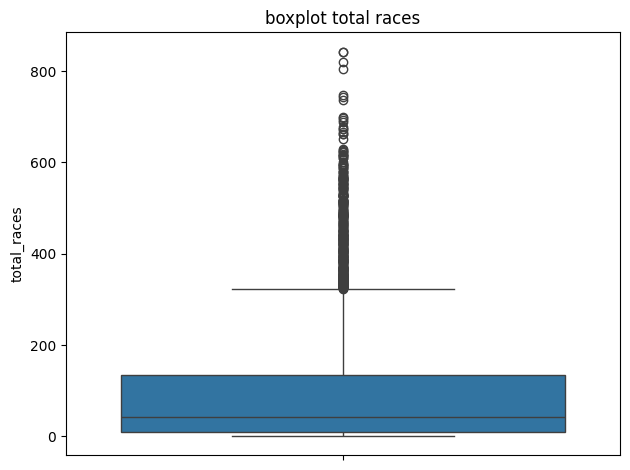

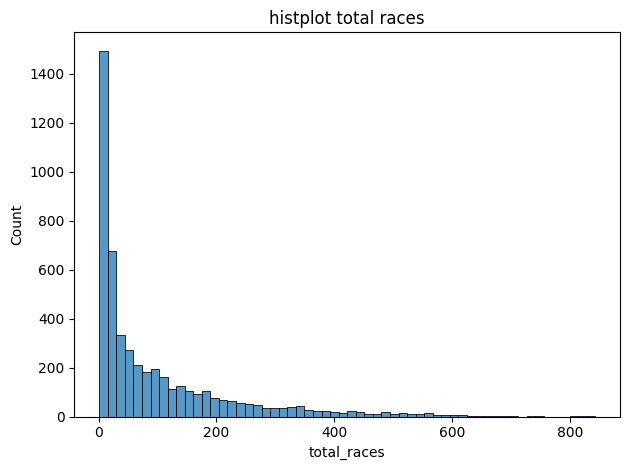

In [18]:
plt.figure()
plt.title("boxplot total races")
sns.boxplot(cyclists['total_races'])
plt.tight_layout()
plt.show()

plt.figure()
plt.title("histplot total races")
sns.histplot(cyclists['total_races'])
plt.tight_layout()
plt.show()

In [ ]:
# Print amount of cyclists with 600+ races
high_race_cyclists = cyclists[cyclists['total_races'] >= 600]
len(high_race_cyclists)

31

In [28]:
# Print amount of cyclists with 1 race
one_race_cyclists = cyclists[cyclists['total_races'] <= 1]
len(one_race_cyclists)

446

- We have a lot of cyclists who made very few races, and very few cyclists who made a lot. Only 31 made +600 races and 446 made only 1 race.
- Let's see what happens if we put a threshold on min/max amount of races.

In [29]:
threshold_down = 10
threshold_up = 600

# Filter out records with 'points' below the threshold
cyclists_threshold = cyclists[(cyclists['total_races'] >= threshold_down) & (cyclists['total_races'] <= threshold_up)]

In [34]:
cyclists_threshold.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3684 entries, 0 to 4890
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   cyclist                                3684 non-null   object 
 1   birth_year                             3684 non-null   int64  
 2   bmi                                    3684 non-null   float64
 3   average_cyclist_age                    3684 non-null   float64
 4   adjusted_points                        3684 non-null   float64
 5   scaled_adjusted_points                 3684 non-null   float64
 6   average_position                       3684 non-null   float64
 7   average_profile                        3684 non-null   float64
 8   average_normalized_position_points     3684 non-null   float64
 9   average_normalized_position_startlist  3684 non-null   float64
 10  total_races                            3684 non-null   int64  
 11  season_1_

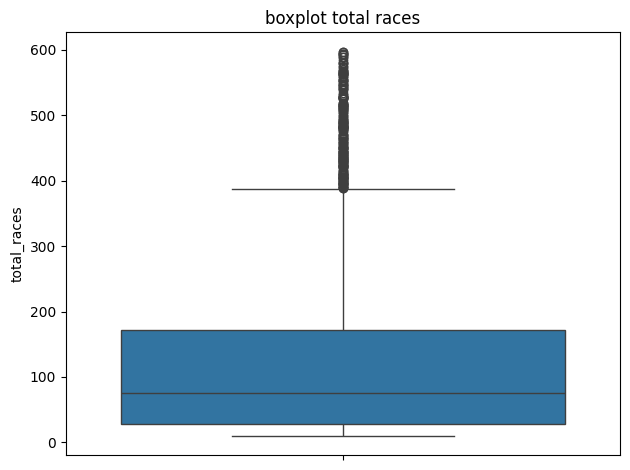

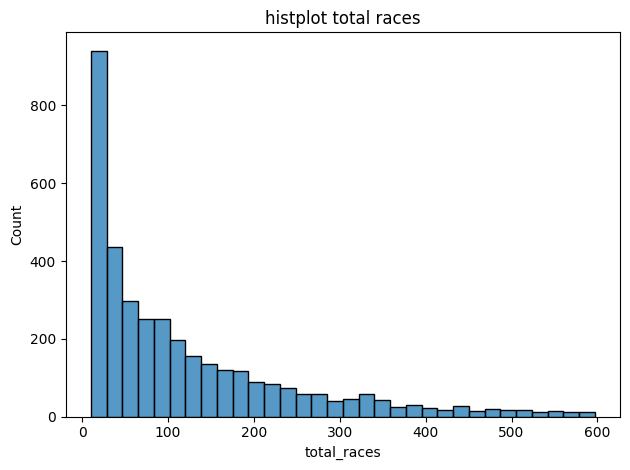

In [31]:
plt.figure()
plt.title("boxplot total races")
sns.boxplot(cyclists_threshold['total_races'])
plt.tight_layout()
plt.show()

plt.figure()
plt.title("histplot total races")
sns.histplot(cyclists_threshold['total_races'])
plt.tight_layout()
plt.show()

- If we put a threshold we quite a lot of cyclists depending on the threshold, so for the moment avoid using threshold.

In [33]:
cyclists.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4892 entries, 0 to 4891
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   cyclist                                4892 non-null   object 
 1   birth_year                             4892 non-null   int64  
 2   bmi                                    4892 non-null   float64
 3   average_cyclist_age                    4892 non-null   float64
 4   adjusted_points                        4892 non-null   float64
 5   scaled_adjusted_points                 4892 non-null   float64
 6   average_position                       4892 non-null   float64
 7   average_profile                        4892 non-null   float64
 8   average_normalized_position_points     4892 non-null   float64
 9   average_normalized_position_startlist  4892 non-null   float64
 10  total_races                            4892 non-null   int64  
 11  seas

- Impute season_x_adp with 0 where is null (it is safe and reasonable because if a cyclist never did a race in a certain season his score is 0). 

In [37]:
columns_to_impute = ['season_1_adp', 'season_2_adp', 'season_3_adp', 'season_4_adp']

# Fill null values with 0 for specified columns
cyclists[columns_to_impute] = cyclists[columns_to_impute].fillna(0)

# Check the result
print(cyclists[columns_to_impute].isnull().sum())  # Should print 0 for all columns


season_1_adp    0
season_2_adp    0
season_3_adp    0
season_4_adp    0
dtype: int64


In [38]:
cyclists.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4892 entries, 0 to 4891
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   cyclist                                4892 non-null   object 
 1   birth_year                             4892 non-null   int64  
 2   bmi                                    4892 non-null   float64
 3   average_cyclist_age                    4892 non-null   float64
 4   adjusted_points                        4892 non-null   float64
 5   scaled_adjusted_points                 4892 non-null   float64
 6   average_position                       4892 non-null   float64
 7   average_profile                        4892 non-null   float64
 8   average_normalized_position_points     4892 non-null   float64
 9   average_normalized_position_startlist  4892 non-null   float64
 10  total_races                            4892 non-null   int64  
 11  seas

- If we drop null rows we end up with 3202 cyclists.

In [39]:
cyclists.dropna().info()

<class 'pandas.core.frame.DataFrame'>
Index: 3202 entries, 0 to 4890
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   cyclist                                3202 non-null   object 
 1   birth_year                             3202 non-null   int64  
 2   bmi                                    3202 non-null   float64
 3   average_cyclist_age                    3202 non-null   float64
 4   adjusted_points                        3202 non-null   float64
 5   scaled_adjusted_points                 3202 non-null   float64
 6   average_position                       3202 non-null   float64
 7   average_profile                        3202 non-null   float64
 8   average_normalized_position_points     3202 non-null   float64
 9   average_normalized_position_startlist  3202 non-null   float64
 10  total_races                            3202 non-null   int64  
 11  season_1_

<Axes: title={'center': 'kendall correlation'}>

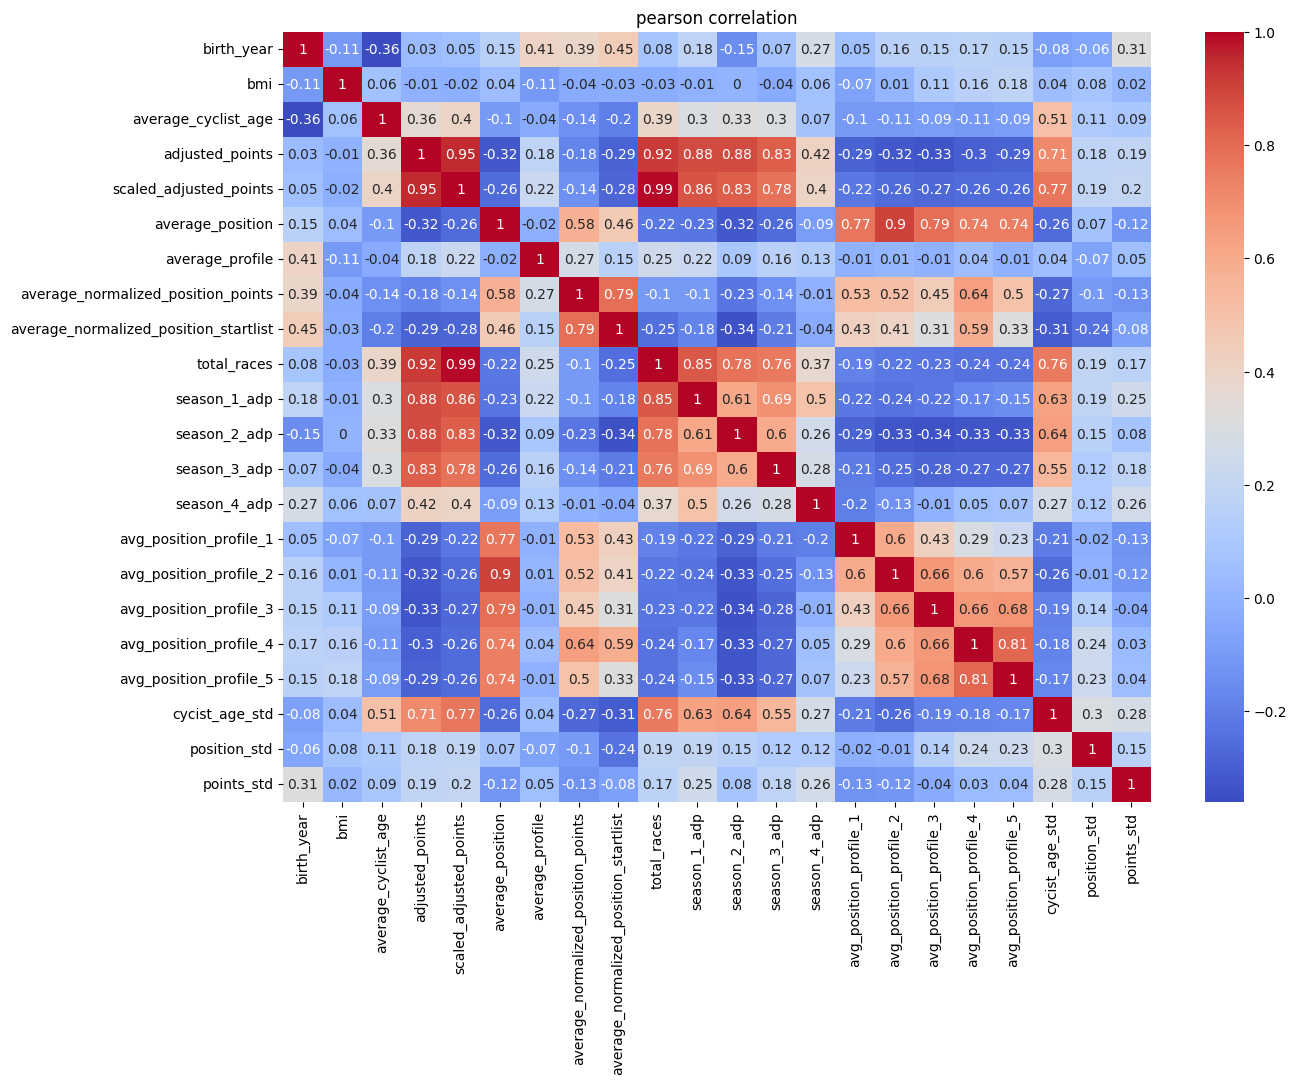

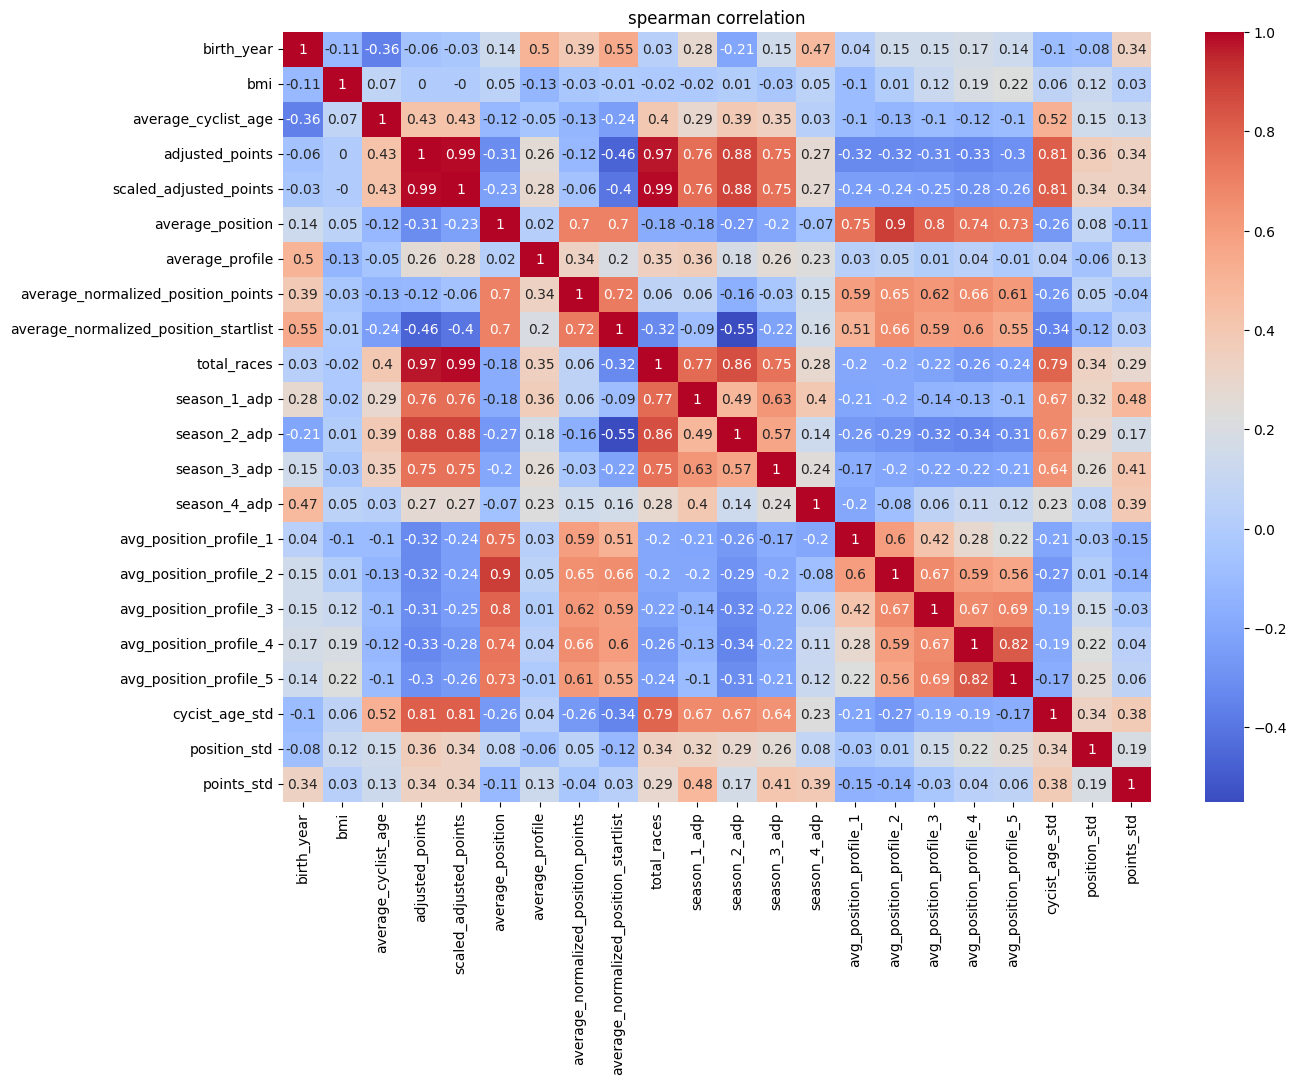

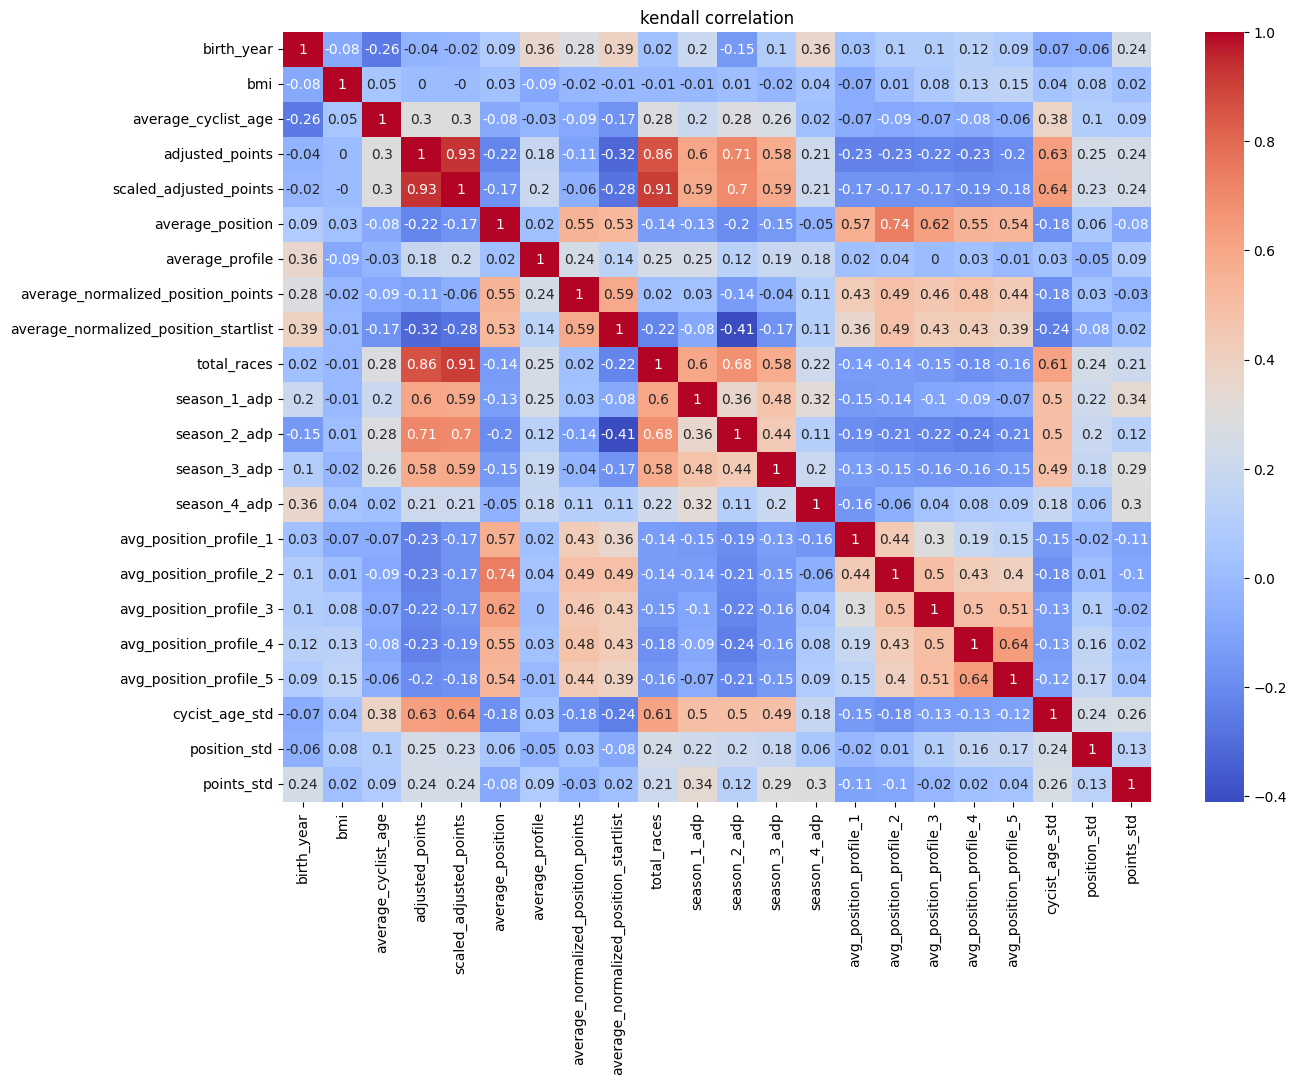

In [42]:
cyclists_numerical = cyclists.select_dtypes(include=[float, int])

correlation = cyclists_numerical.corr('pearson')

plt.figure(figsize=(14, 10))
plt.title('pearson correlation')

sns.heatmap(correlation.round(2),annot=True, cmap='coolwarm')

correlation = cyclists_numerical.corr('spearman')

plt.figure(figsize=(14, 10))
plt.title('spearman correlation')
sns.heatmap(correlation.round(2),annot=True, cmap='coolwarm')

correlation = cyclists_numerical.corr('kendall')

plt.figure(figsize=(14, 10))
plt.title('kendall correlation')

sns.heatmap(correlation.round(2),annot=True, cmap='coolwarm')

- Visualize new features with histograms and boxplots.

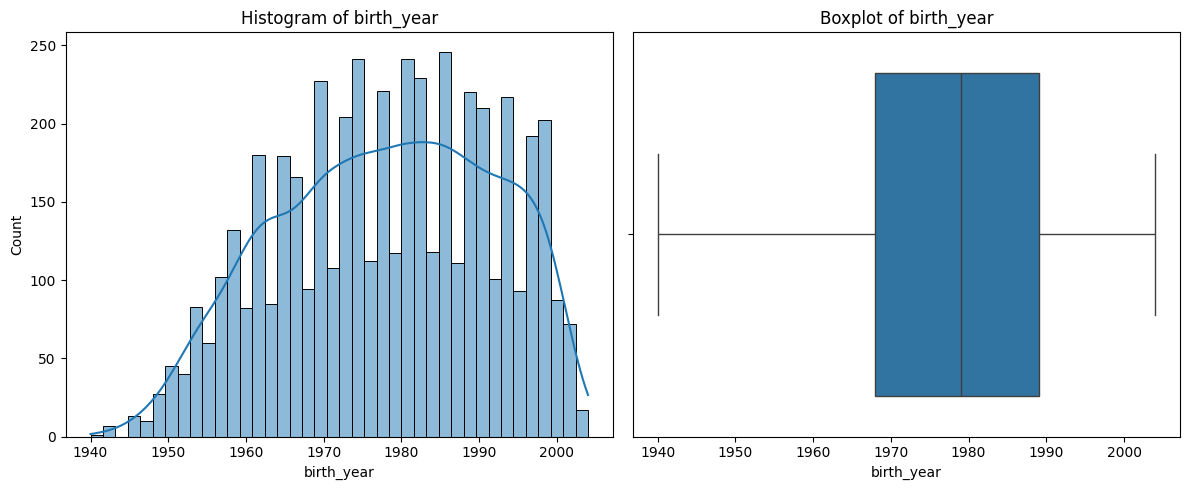

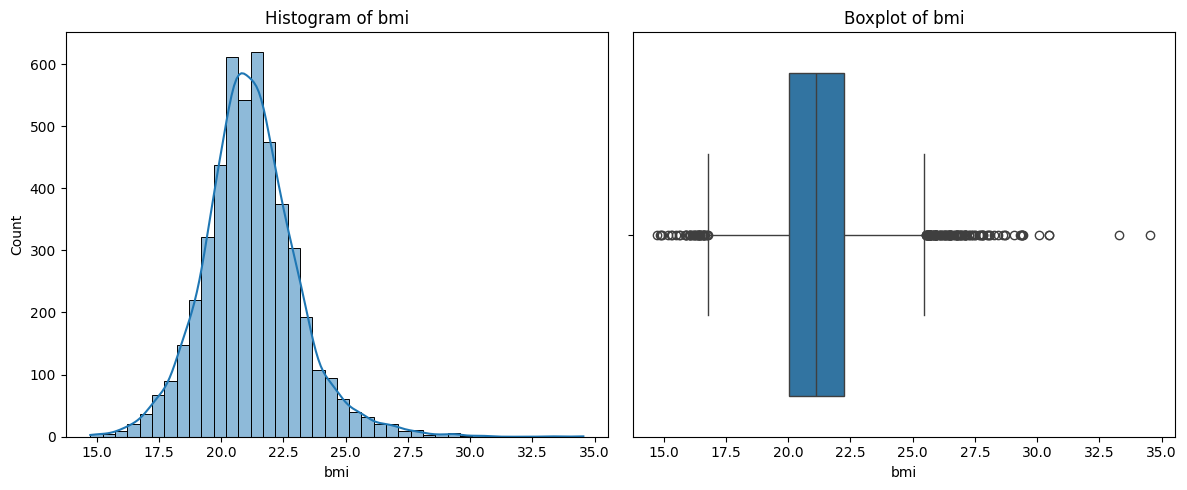

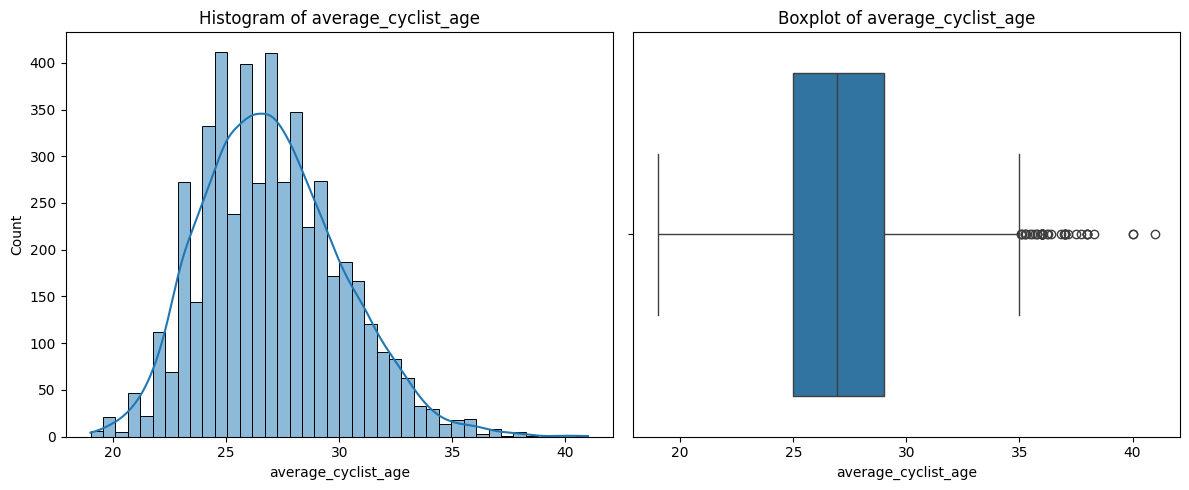

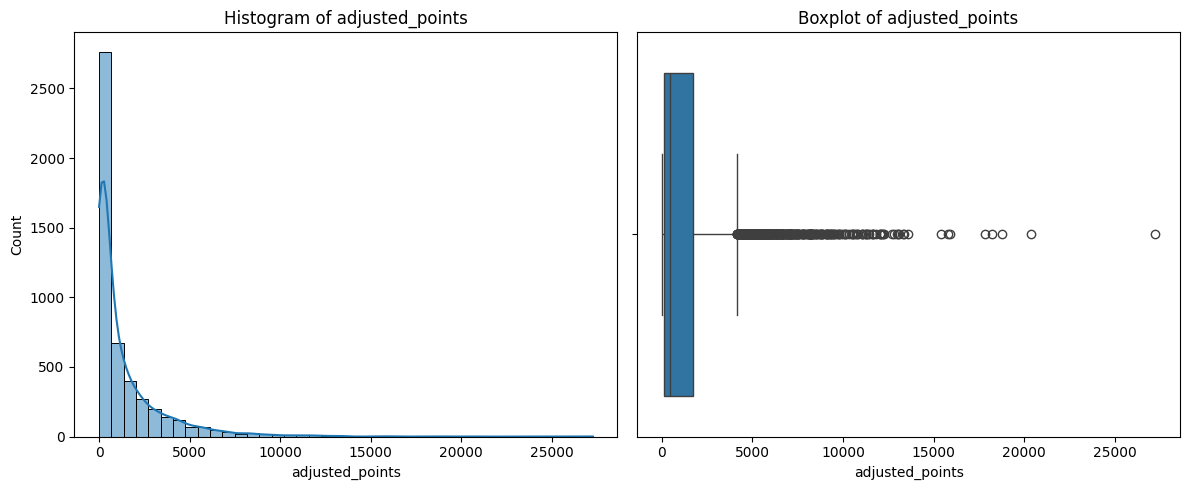

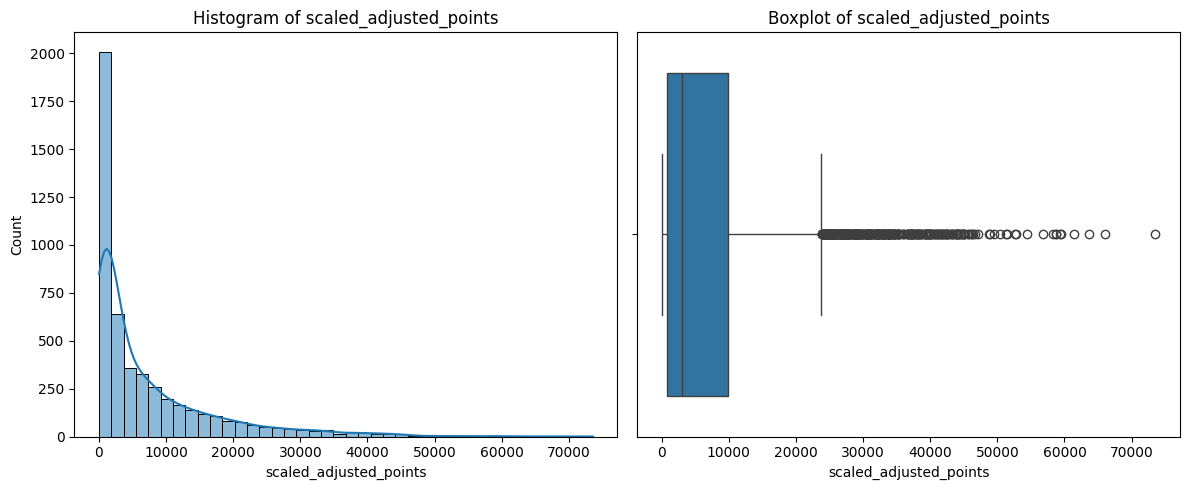

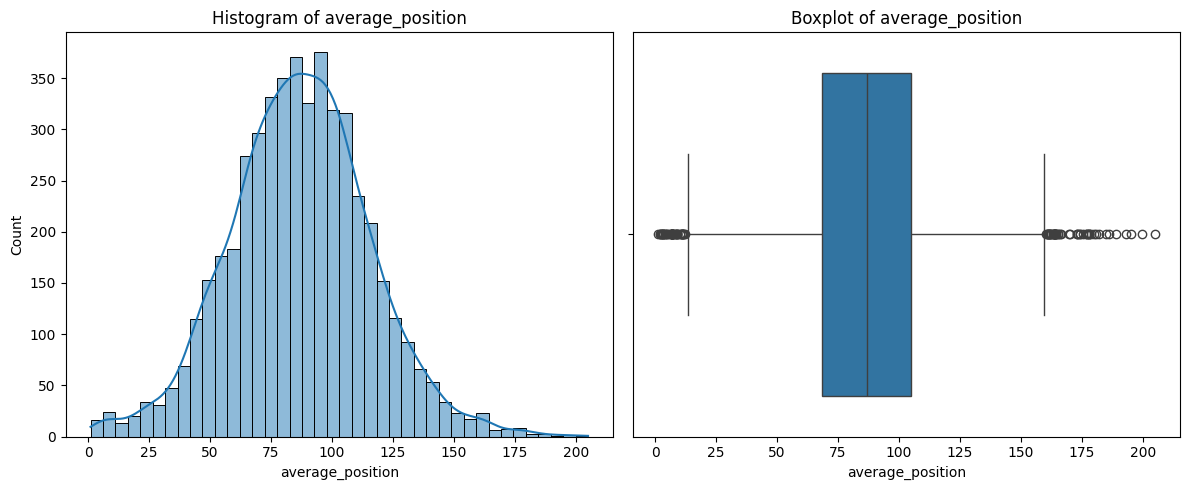

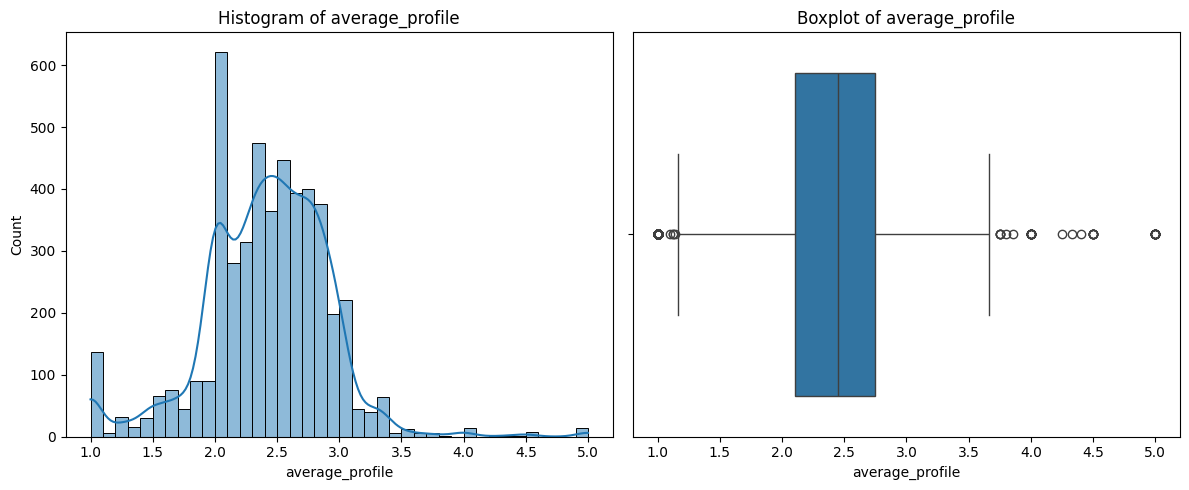

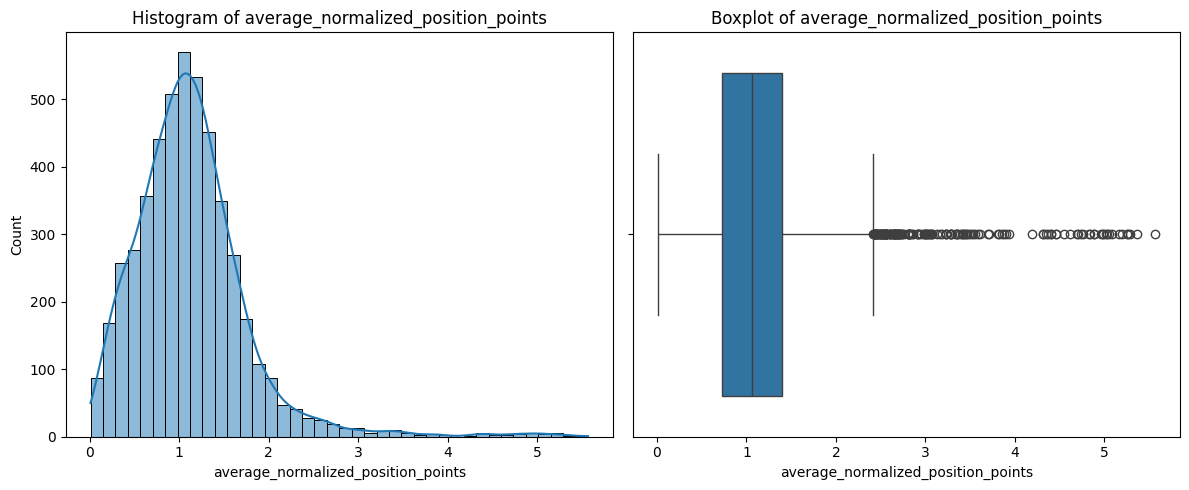

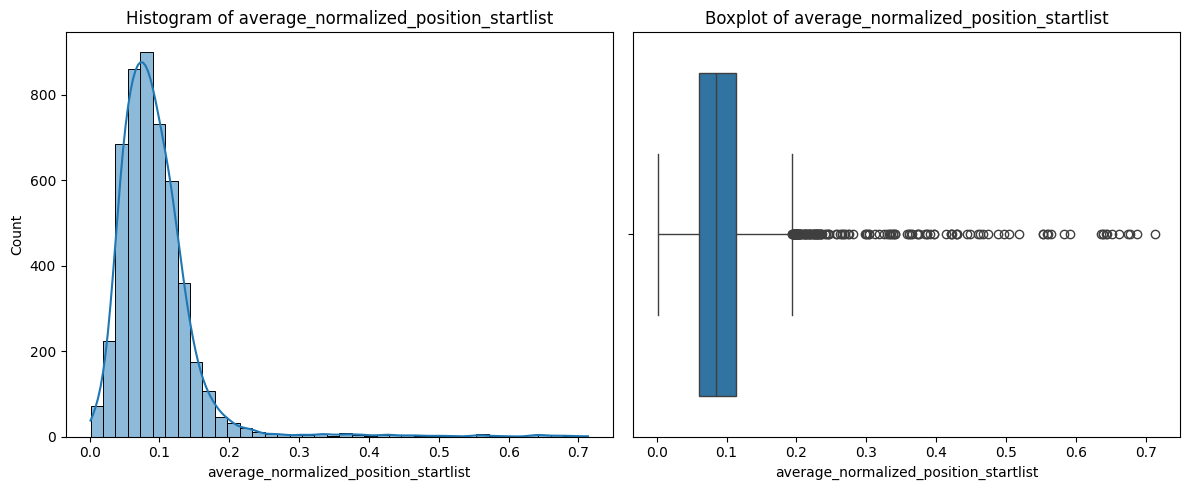

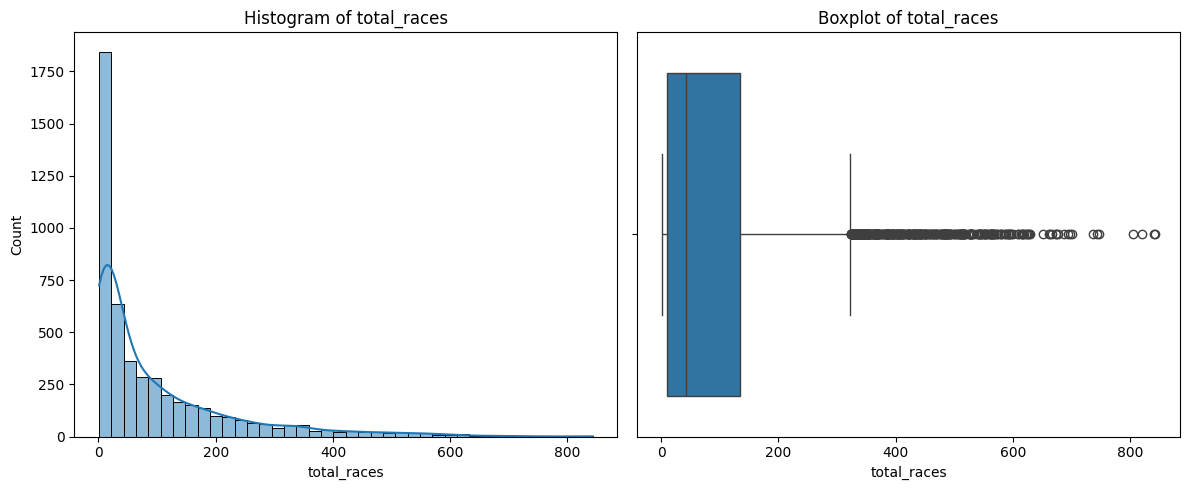

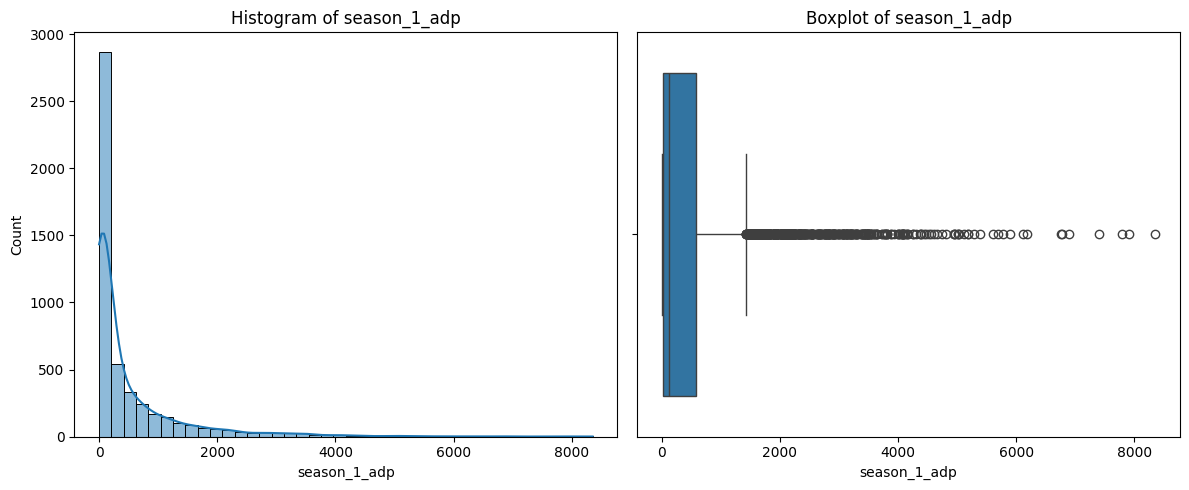

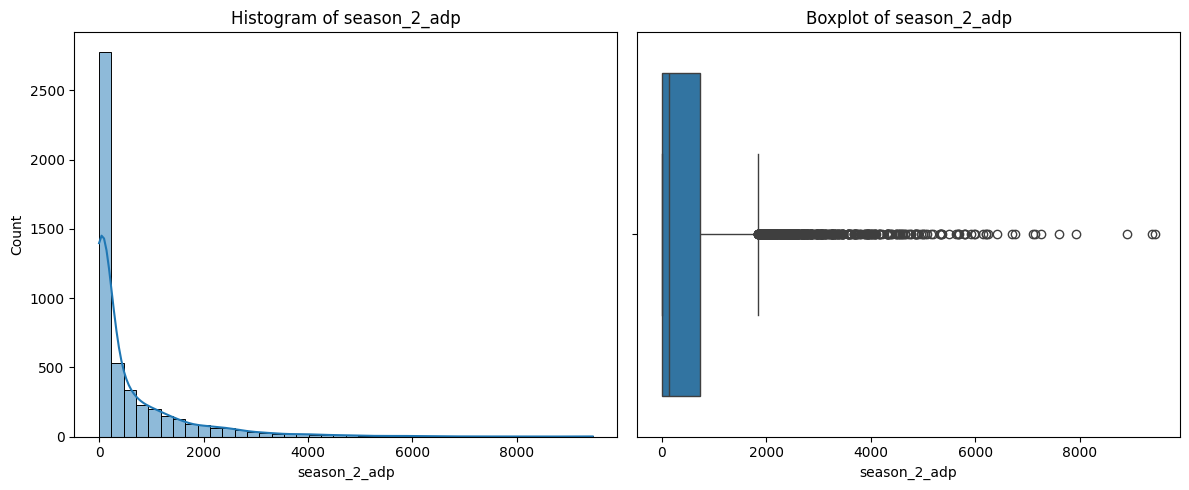

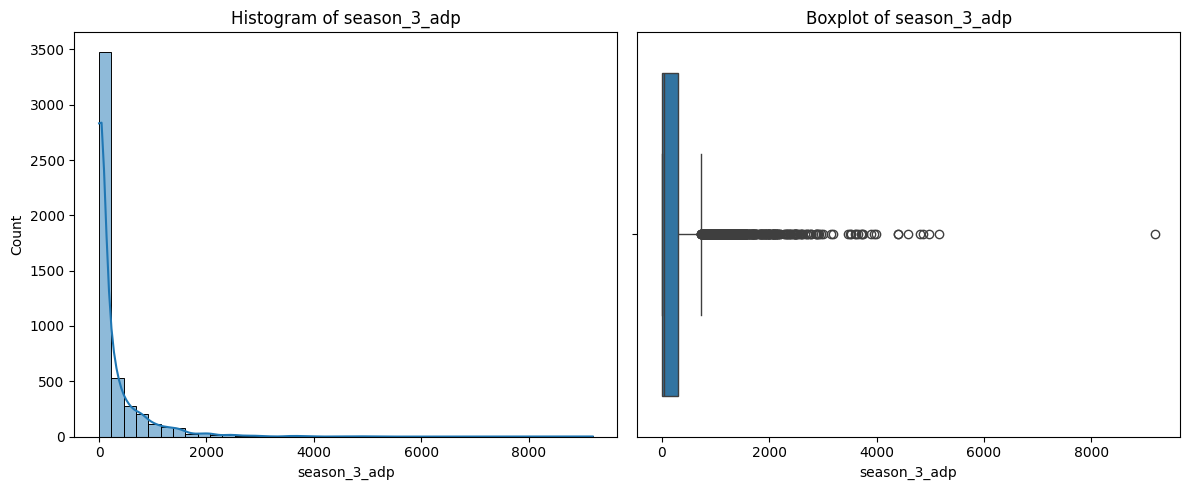

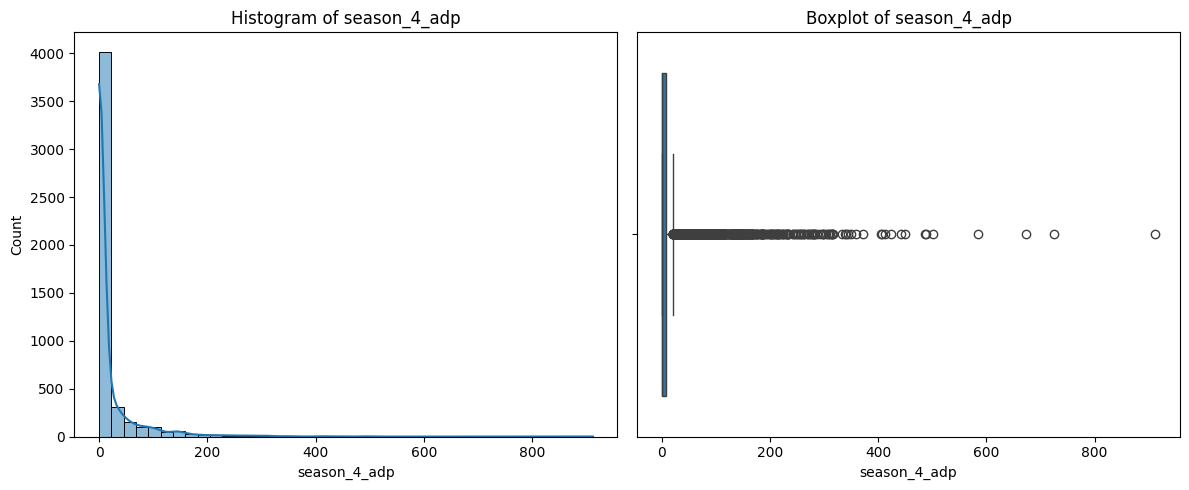

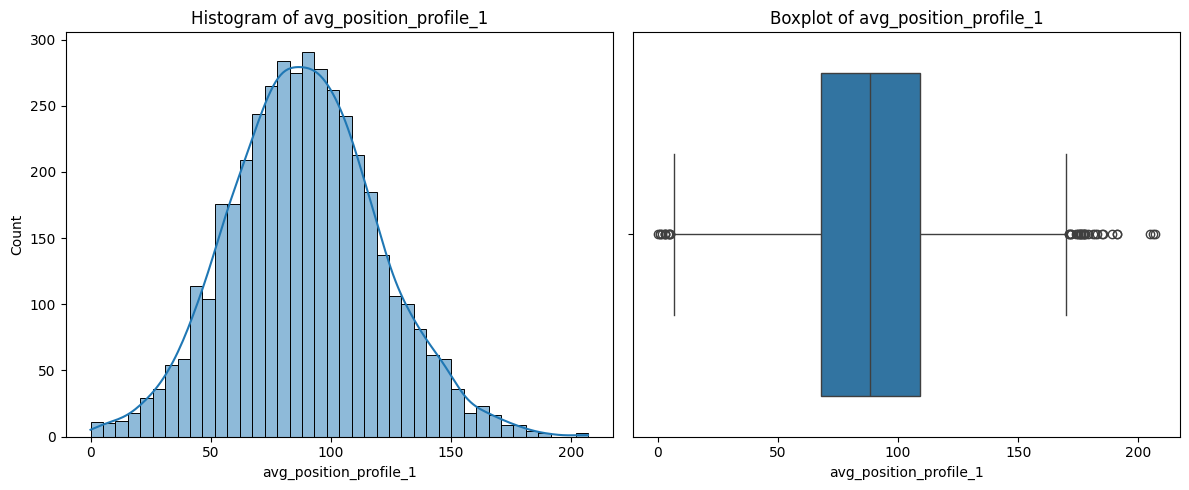

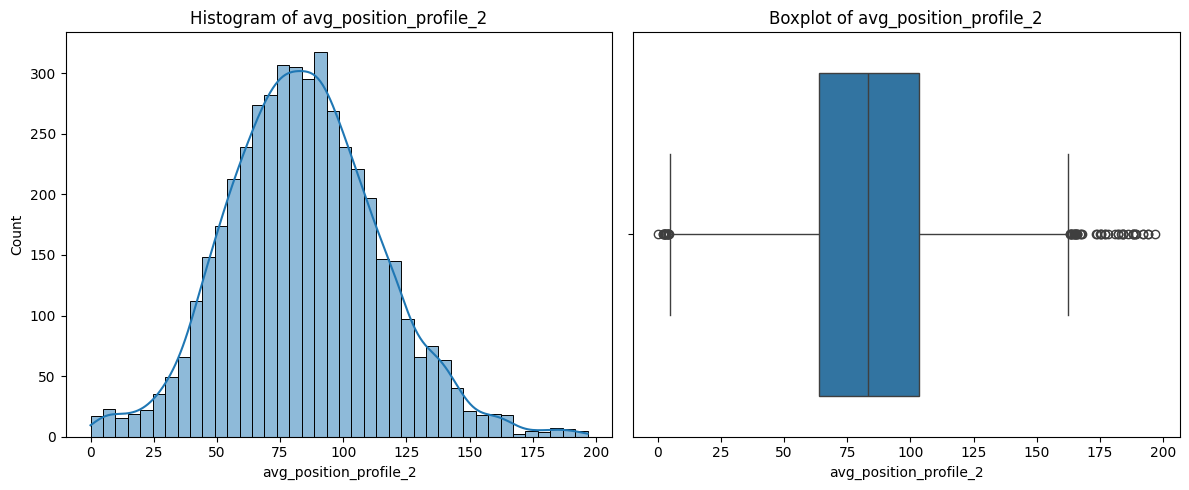

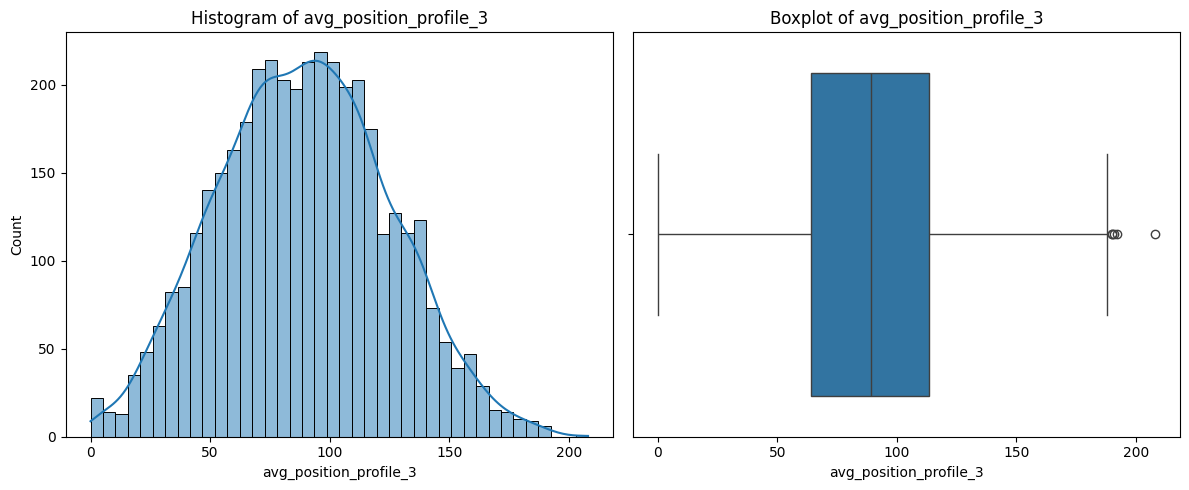

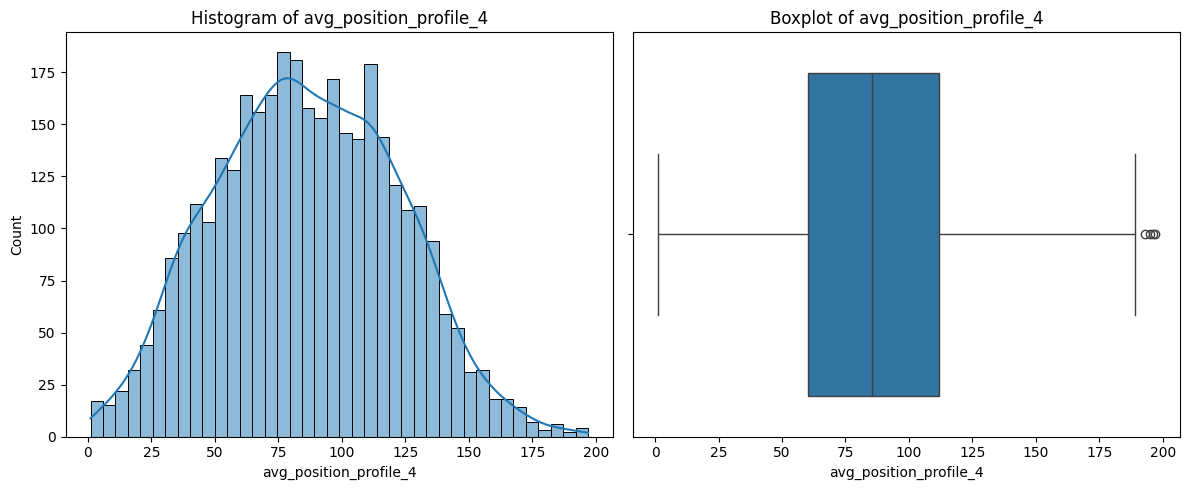

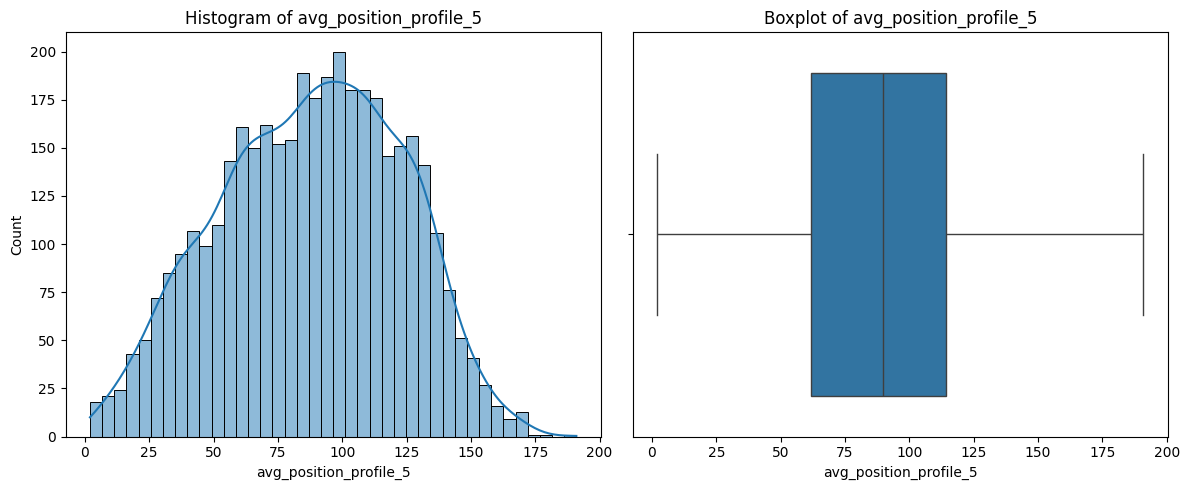

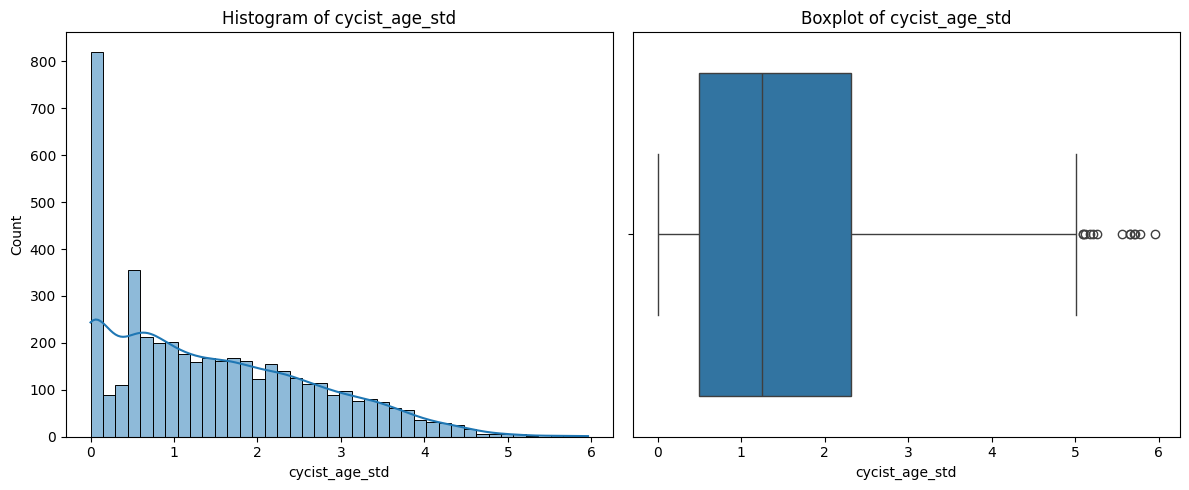

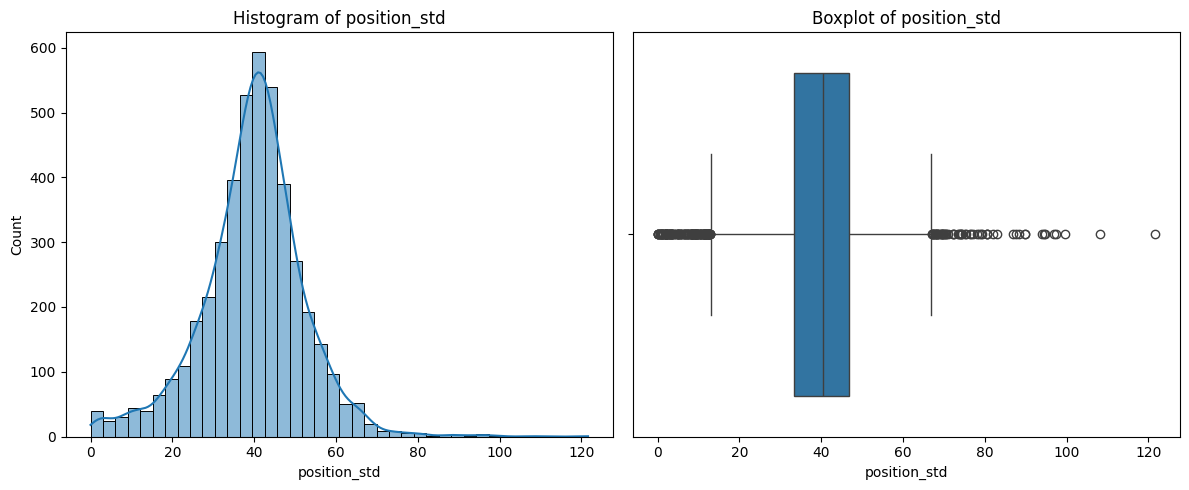

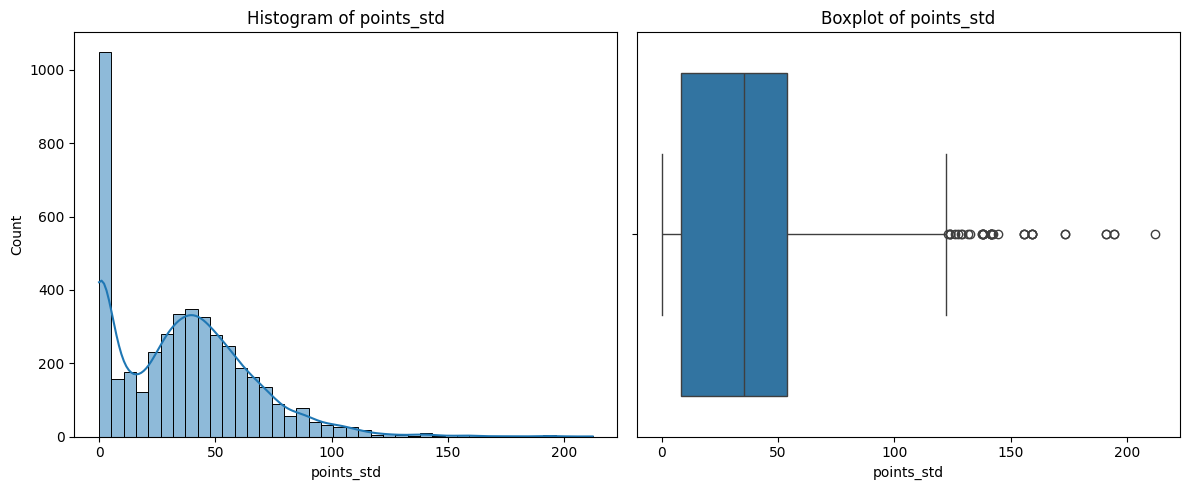

In [43]:
columns_to_select = cyclists.select_dtypes(include=[float, int])

for col in columns_to_select:
    # Crea una figura con due subplot affiancati
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Istogramma
    sns.histplot(cyclists[col].dropna(), bins=40, kde=True, edgecolor='black', ax=axes[0])
    axes[0].set_title(f'Histogram of {col}')
    
    # Boxplot
    sns.boxplot(x=cyclists[col].dropna(), ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')
    
    # Layout ordinato
    plt.tight_layout()
    plt.show()

- Let's print the 5 top cyclist according to 'adjusted_points'

In [44]:
top_cyclists = cyclists['adjusted_points'].sort_values(ascending=False).head(5)
print(cyclists.loc[top_cyclists.index, 'cyclist'])

104     alejandro-valverde
3799           peter-sagan
3826      philippe-gilbert
1756     greg-van-avermaet
4737       vincenzo-nibali
Name: cyclist, dtype: object


Outliers are mainly correlated to very performing cyclists (Wikipedia Links):
- [Alejandro-Valverde](https://it.wikipedia.org/wiki/Alejandro_Valverde)
- [Peter-Sagan](https://it.wikipedia.org/wiki/Peter_Sagan)
- [Philippe-Gilbert](https://it.wikipedia.org/wiki/Philippe_Gilbert)
- [Greg-Van-Avermaet](https://it.wikipedia.org/wiki/Greg_Van_Avermaet)
- [Vincenzo-Nibali](https://it.wikipedia.org/wiki/Vincenzo_Nibali)

We can work with this kind of cyclists or treat them as "extraordinary" cyclists and cut them out from the study.

- Put a threshold to adjusted_points and visualize.

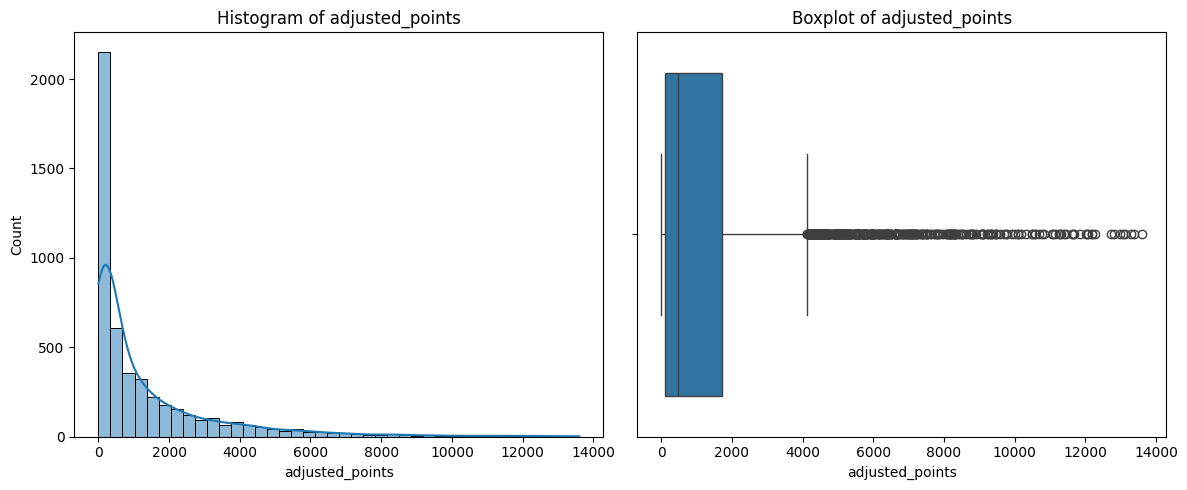

In [ ]:
columns_to_select = ['adjusted_points']
tmp = cyclists[cyclists['adjusted_points'] < 15000]

for col in columns_to_select:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Istogramma
    sns.histplot(tmp[col].dropna(), bins=40, kde=True, edgecolor='black', ax=axes[0])
    axes[0].set_title(f'Histogram of {col}')
    
    # Boxplot
    sns.boxplot(x=tmp[col].dropna(), ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()

In [28]:
import pickle
import gzip

save = True

if save:
    with gzip.open('cyclist_nf.pkl', 'wb') as file:
        pickle.dump(cyclists, file)